In [145]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from time import time

# Task 1: Build the Graph
# Take raw delivery data → figure out which hubs connect to which → calculate how delayed each route typically is → build a graph.
# Task 2: Find Bottleneck Hubs
# Some hubs cause the most delays. Find them using math (betweenness centrality = how many routes pass through this hub). If a hub is on every route AND is slow → it's a chokepoint.
# Task 3: Better ETA(estimated time of arrival) Prediction
# Currently OSRM predicts ETAs ignoring the graph. You'll build:
# A basic model (using simple features like distance, time of day)
# A graph-enhanced model (that also uses "this hub is historically slow")
# Show the graph model is more accurate
# Task 4: FTL vs Carting Decision
# FTL = Full Truck Load (one truck, direct route, expensive but fast)
# Carting = Shared transport (cheaper but slower, goes through hubs)
# Build a framework that recommends which to use based on the corridor and timing.
# Task 5: Strategy Memo
# Write a 1-2 page report for a business leader (not technical) saying:
# "These 5 hubs are your biggest problems"
# "Here's what to do about them"
# "Here's how much money you'll save"


# This project sounds like you need to know GraphSAGE, node2vec, ML pipelines, graph theory — all at once. You don't. Here's the secret:

# 80% of the value comes from Tasks 1, 2, and 5. The graph model (Task 3) can be a simple gradient boosting model with graph features added. That's enough to "demonstrably outperform" a baseline.

In [87]:
df=pd.read_csv('/Users/shabadpreetsingh/Downloads/IITG Project/delivery_data.csv')
df.head(5)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 4:27:55,10.435660,14,11,11.9653,1.272727,14,11,11.9653,1.272727
1,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 4:17:55,18.936842,24,20,21.7243,1.200000,10,9,9.7590,1.111111
2,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 4:01:20,27.637279,40,28,32.5395,1.428571,16,7,10.8152,2.285714
3,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 3:39:57,36.118028,62,40,45.5620,1.550000,21,12,13.0224,1.750000
4,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 3:33:55,39.386040,68,44,54.2181,1.545455,6,5,3.9153,1.200000


In [88]:
df.shape

(144867, 24)

In [89]:
delivery_data=df.copy()

In [90]:
delivery_data.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [91]:
delivery_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  int64  
 12  is_cutoff       

In [92]:
#jo rows puri nahi hai
#source_name                     144574
#destination_name                144606

In [93]:
delivery_data.describe(include='all')

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867,144867,144867,144867,144867,144867,144574,144867,144606,144867,...,144867,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
unique,2,14754,1504,2,14817,1508,1498,1481,1468,26117,...,92967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,training,2018-09-13 19:44:52,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153811219535896559,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-18 20:24:47,...,2018-09-24 5:19:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,104858,122,1812,99660,101,23347,23347,15192,15192,81,...,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000


In [94]:
df.dtypes

data                               object
trip_creation_time                 object
route_schedule_uuid                object
route_type                         object
trip_uuid                          object
source_center                      object
source_name                        object
destination_center                 object
destination_name                   object
od_start_time                      object
od_end_time                        object
start_scan_to_end_scan              int64
is_cutoff                            bool
cutoff_factor                       int64
cutoff_timestamp                   object
actual_distance_to_destination    float64
actual_time                         int64
osrm_time                           int64
osrm_distance                     float64
factor                            float64
segment_actual_time                 int64
segment_osrm_time                   int64
segment_osrm_distance             float64
segment_factor                    

In [95]:
#trip_creation_time                 object-date time ch
#od_start_time                      object-date time ch
#od_end_time                        object-date time ch
#cutoff_timestamp                   object-date time ch convert karna


In [96]:
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['od_start_time'] = pd.to_datetime(df['od_start_time'])
df['od_end_time'] = pd.to_datetime(df['od_end_time'])
df['cutoff_timestamp'] = pd.to_datetime(df['cutoff_timestamp'])

In [97]:
df.dtypes

data                                      object
trip_creation_time                datetime64[ns]
route_schedule_uuid                       object
route_type                                object
trip_uuid                                 object
source_center                             object
source_name                               object
destination_center                        object
destination_name                          object
od_start_time                     datetime64[ns]
od_end_time                       datetime64[ns]
start_scan_to_end_scan                     int64
is_cutoff                                   bool
cutoff_factor                              int64
cutoff_timestamp                  datetime64[ns]
actual_distance_to_destination           float64
actual_time                                int64
osrm_time                                  int64
osrm_distance                            float64
factor                                   float64
segment_actual_time 

In [98]:
#test and training ko split kar diya
training_data = delivery_data[delivery_data['data'] == 'training']
test_data = delivery_data[delivery_data['data'] == 'test']

In [99]:
test_data.shape

(40009, 24)

In [100]:
training_data.shape

(104858, 24)

In [101]:
training_data

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 4:27:55,10.435660,14,11,11.9653,1.272727,14,11,11.9653,1.272727
1,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 4:17:55,18.936842,24,20,21.7243,1.200000,10,9,9.7590,1.111111
2,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 4:01:20,27.637279,40,28,32.5395,1.428571,16,7,10.8152,2.285714
3,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 3:39:57,36.118028,62,40,45.5620,1.550000,21,12,13.0224,1.750000
4,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 3:33:55,39.386040,68,44,54.2181,1.545455,6,5,3.9153,1.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,training,2018-09-20 16:24:28,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28,...,2018-09-20 21:57:20,45.258278,94,60,67.9280,1.566667,12,12,8.1858,1.000000
144863,training,2018-09-20 16:24:28,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28,...,2018-09-20 21:31:18,54.092531,120,76,85.6829,1.578947,26,21,17.3725,1.238095
144864,training,2018-09-20 16:24:28,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28,...,2018-09-20 21:11:18,66.163591,140,88,97.0933,1.590909,20,34,20.7053,0.588235
144865,training,2018-09-20 16:24:28,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28,...,2018-09-20 20:53:19,73.680667,158,98,111.2709,1.612245,17,27,18.8885,0.629630


In [102]:
delivery_data[delivery_data['source_name'].isnull()]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
112,training,2018-09-25 8:53:04,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 6:58:08,...,2018-09-26 14:09:19,22.783440,48,34,37.7749,1.411765,48,34,37.7749,1.411765
113,training,2018-09-25 8:53:04,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 6:58:08,...,2018-09-26 13:19:23,46.071250,98,41,56.3575,2.390244,49,33,34.1661,1.484848
114,training,2018-09-25 8:53:04,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 6:58:08,...,2018-09-26 12:49:33,67.714994,127,58,80.4811,2.189655,29,17,24.1236,1.705882
115,training,2018-09-25 8:53:04,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 6:58:08,...,2018-09-26 12:21:18,88.149642,156,73,101.2556,2.136986,28,14,20.7746,2.000000
116,training,2018-09-25 8:53:04,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 6:58:08,...,2018-09-26 11:25:24,112.691981,212,92,127.9860,2.304348,55,18,26.7304,3.055556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144484,test,2018-10-03 9:06:07,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND282002AAD,NaN,IND474003AAA,Gwalior_HrihrNgr_I (Madhya Pradesh),2018-10-03 17:34:22,...,2018-10-03 20:54:08,45.134384,62,45,47.7734,1.377778,34,23,23.6601,1.478261
144485,test,2018-10-03 9:06:07,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND282002AAD,NaN,IND474003AAA,Gwalior_HrihrNgr_I (Madhya Pradesh),2018-10-03 17:34:22,...,2018-10-03 20:30:09,66.542266,86,71,71.9549,1.211268,23,25,24.1815,0.920000
144486,test,2018-10-03 9:06:07,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND282002AAD,NaN,IND474003AAA,Gwalior_HrihrNgr_I (Madhya Pradesh),2018-10-03 17:34:22,...,2018-10-03 20:00:08,88.143957,116,114,112.6943,1.017544,30,43,40.7394,0.697674
144487,test,2018-10-03 9:06:07,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND282002AAD,NaN,IND474003AAA,Gwalior_HrihrNgr_I (Madhya Pradesh),2018-10-03 17:34:22,...,2018-10-03 19:02:11,111.084417,173,123,134.1940,1.406504,57,45,46.9217,1.266667


In [103]:
delivery_data[delivery_data['destination_name'].isnull()]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
110,training,2018-09-25 8:53:04,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342601AAA,Piparcity_BsstdDPP_D (Rajasthan),IND342902A1B,NaN,2018-09-26 5:04:49,...,2018-09-26 5:57:25,24.538214,58,33,30.8845,1.757576,58,33,30.8845,1.757576
111,training,2018-09-25 8:53:04,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342601AAA,Piparcity_BsstdDPP_D (Rajasthan),IND342902A1B,NaN,2018-09-26 5:04:49,...,2018-09-26 5:04:49,34.657709,110,43,41.5361,2.558140,52,10,10.6517,5.200000
982,test,2018-10-01 20:56:18,thanos::sroute:d0ebdacd-e09b-47d3-be77-c9c4a05...,FTL,trip-153842737815495661,IND573103AAA,Arsikere_HsnRdDPP_D (Karnataka),IND577116AAA,NaN,2018-10-02 1:22:21,...,2018-10-02 1:38:30,22.029639,21,16,22.9630,1.312500,21,16,22.9630,1.312500
983,test,2018-10-01 20:56:18,thanos::sroute:d0ebdacd-e09b-47d3-be77-c9c4a05...,FTL,trip-153842737815495661,IND573103AAA,Arsikere_HsnRdDPP_D (Karnataka),IND577116AAA,NaN,2018-10-02 1:22:21,...,2018-10-02 1:23:30,35.528960,36,25,36.5050,1.440000,15,9,13.5420,1.666667
4882,training,2018-09-24 7:18:06,thanos::sroute:2f43f11e-d3ba-4590-9355-82928e1...,FTL,trip-153777348608709328,IND202001AAB,Aligarh_KhirByps_I (Uttar Pradesh),IND282002AAD,NaN,2018-09-24 15:02:14,...,2018-09-24 18:06:49,22.193687,40,26,28.9817,1.538462,40,26,28.9817,1.538462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144478,test,2018-10-03 9:06:07,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND282002AAD,NaN,2018-10-03 9:06:07,...,2018-10-03 15:42:11,89.773705,108,70,99.4096,1.542857,21,16,23.3595,1.312500
144479,test,2018-10-03 9:06:07,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND282002AAD,NaN,2018-10-03 9:06:07,...,2018-10-03 15:12:10,110.854079,138,94,124.6598,1.468085,30,24,25.2502,1.250000
144480,test,2018-10-03 9:06:07,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND282002AAD,NaN,2018-10-03 9:06:07,...,2018-10-03 12:26:08,132.514233,304,119,147.2295,2.554622,166,24,22.5697,6.916667
144481,test,2018-10-03 9:06:07,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND282002AAD,NaN,2018-10-03 9:06:07,...,2018-10-03 11:52:20,154.024566,337,130,177.2394,2.592308,33,27,24.9784,1.222222


In [124]:
delivery_data.loc[110]

#* pandas row 110
    # = Excel visible row 112

data                                                                       training
trip_creation_time                                               2018-09-25 8:53:04
route_schedule_uuid               thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...
route_type                                                                      FTL
trip_uuid                                                   trip-153786558437756691
source_center                                                          IND342601AAA
source_name                                        Piparcity_BsstdDPP_D (Rajasthan)
destination_center                                                     IND342902A1B
destination_name                                                                NaN
od_start_time                                                    2018-09-26 5:04:49
od_end_time                                                      2018-09-26 6:58:08
start_scan_to_end_scan                                                      

In [134]:
delivery_data[
    delivery_data['source_name'].isnull()
]['source_center'].unique()

#10 hai

array(['IND342902A1B', 'IND577116AAA', 'IND282002AAD', 'IND465333A1B',
       'IND841301AAC', 'IND509103AAC', 'IND126116AAA', 'IND331022A1B',
       'IND505326AAB', 'IND852118A1B'], dtype=object)

In [136]:
delivery_data[
    delivery_data['destination_name'].isnull()
]['destination_center'].unique()

#13 hai

array(['IND342902A1B', 'IND577116AAA', 'IND282002AAD', 'IND465333A1B',
       'IND841301AAC', 'IND505326AAB', 'IND852118A1B', 'IND126116AAA',
       'IND509103AAC', 'IND221005A1A', 'IND250002AAC', 'IND331001A1C',
       'IND122015AAC'], dtype=object)

In [138]:
delivery_data[
    (delivery_data['source_name'].isnull()) &
    (delivery_data['destination_name'].isnull())
]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
68006,training,2018-09-26 22:21:57,thanos::sroute:cfb575b8-df26-48f5-8427-6f48f9d...,FTL,trip-153800051661903546,IND331022A1B,NaN,IND331001A1C,NaN,2018-09-27 3:19:15,...,2018-09-27 5:01:28,25.178605,26,23,25.7246,1.130435,26,23,25.7246,1.130435
68007,training,2018-09-26 22:21:57,thanos::sroute:cfb575b8-df26-48f5-8427-6f48f9d...,FTL,trip-153800051661903546,IND331022A1B,NaN,IND331001A1C,NaN,2018-09-27 3:19:15,...,2018-09-27 3:33:17,45.101167,114,44,54.6110,2.590909,88,21,28.8863,4.190476
68008,training,2018-09-26 22:21:57,thanos::sroute:cfb575b8-df26-48f5-8427-6f48f9d...,FTL,trip-153800051661903546,IND331022A1B,NaN,IND331001A1C,NaN,2018-09-27 3:19:15,...,2018-09-27 3:19:20,50.844665,128,49,60.9205,2.612245,13,4,6.3096,3.250000


In [141]:
list1 = [
    'IND342902A1B', 'IND577116AAA', 'IND282002AAD',
    'IND465333A1B', 'IND841301AAC', 'IND509103AAC',
    'IND126116AAA', 'IND331022A1B', 'IND505326AAB',
    'IND852118A1B'
]

list2 = [
    'IND342902A1B', 'IND577116AAA', 'IND282002AAD',
    'IND465333A1B', 'IND841301AAC', 'IND505326AAB',
    'IND852118A1B', 'IND126116AAA', 'IND509103AAC',
    'IND221005A1A', 'IND250002AAC', 'IND331001A1C',
    'IND122015AAC'
]

common_values = set(list1) & set(list2)

print(common_values)

{'IND505326AAB', 'IND465333A1B', 'IND509103AAC', 'IND282002AAD', 'IND342902A1B', 'IND577116AAA', 'IND852118A1B', 'IND126116AAA', 'IND841301AAC'}


In [149]:
print(delivery_data['route_type'].value_counts())
#counts FTL v/s Carting values

route_type
FTL        99660
Carting    45207
Name: count, dtype: int64


In [151]:
#factor jo ki most important cheez hai usse samajhna
print(delivery_data['factor'].describe())
#min max important hoga

count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: factor, dtype: float64


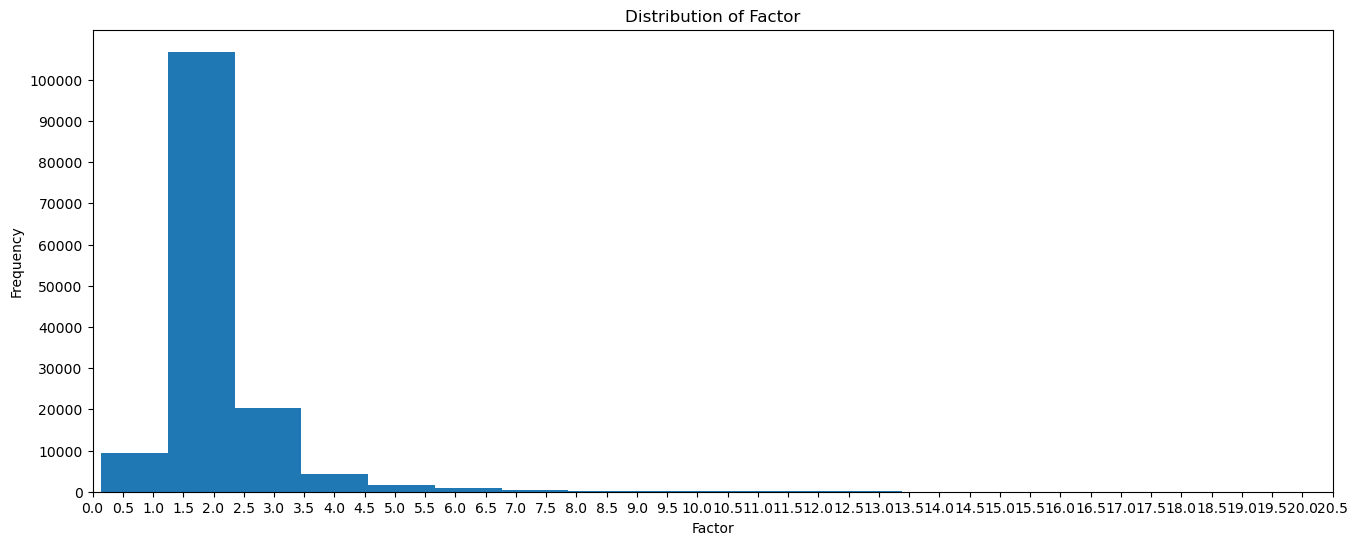

In [199]:
plt.figure(figsize=(16,6))

plt.hist(delivery_data['factor'], bins=70)
plt.xlim(0,20)
plt.yticks(np.arange(0, 110000, 10000))
plt.xticks(np.arange(0, 21, .5))
plt.xlabel('Factor')
plt.ylabel('Frequency')
plt.title('Distribution of Factor')

plt.show()

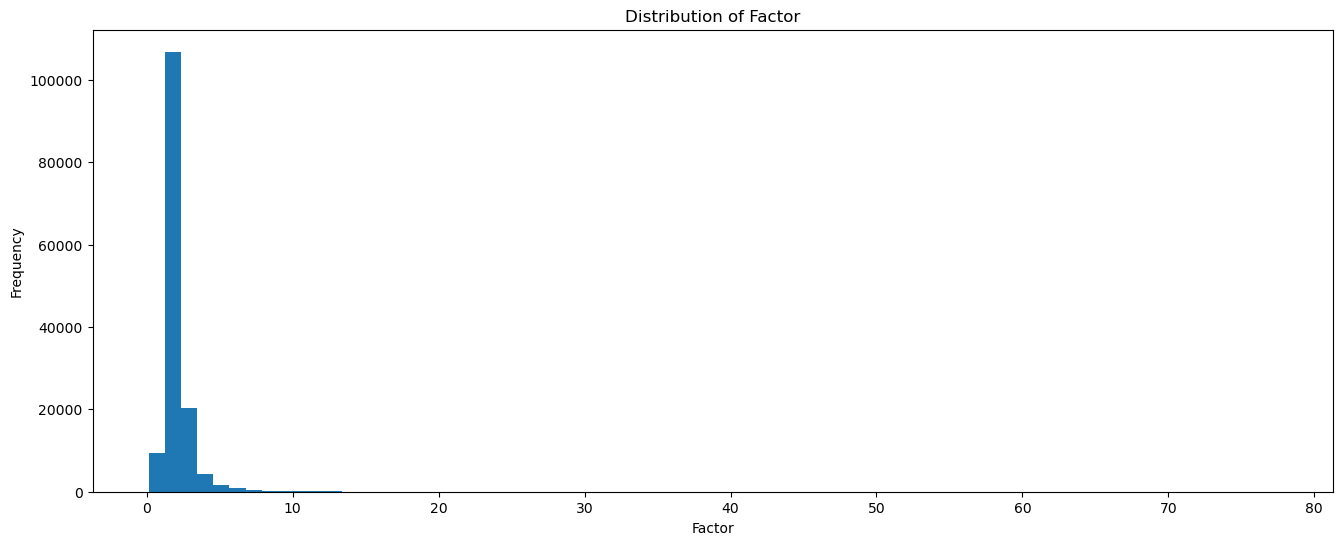

In [210]:
plt.figure(figsize=(16,6))

plt.hist(delivery_data['factor'], bins=70)

plt.xlabel('Factor')
plt.ylabel('Frequency')
plt.title('Distribution of Factor')

plt.show()

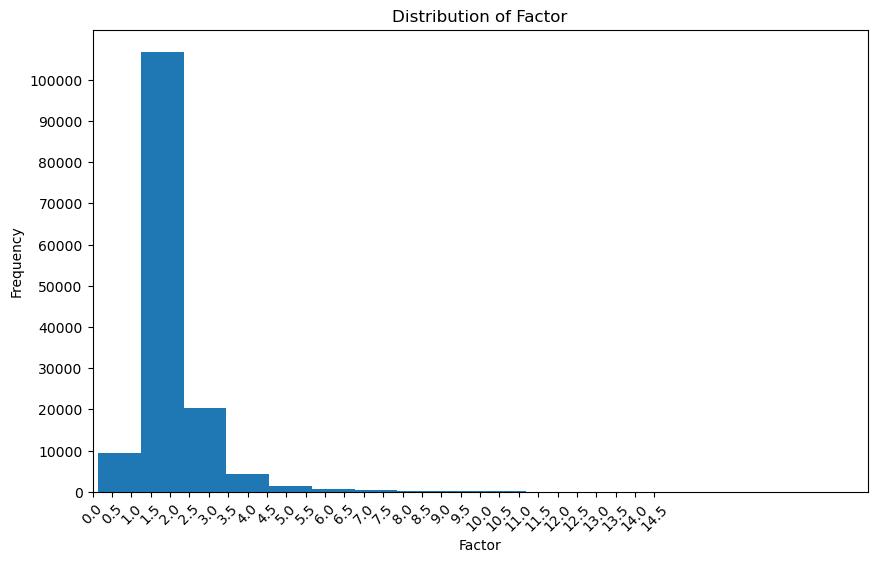

In [214]:
plt.figure(figsize=(10,6))

plt.hist(delivery_data['factor'], bins=70)

plt.xlim(0,20)

plt.yticks(np.arange(0, 110000, 10000))

plt.xticks(
    np.arange(0, 15, 0.5),
    rotation=45
)

plt.xlabel('Factor')
plt.ylabel('Frequency')
plt.title('Distribution of Factor')

plt.show()

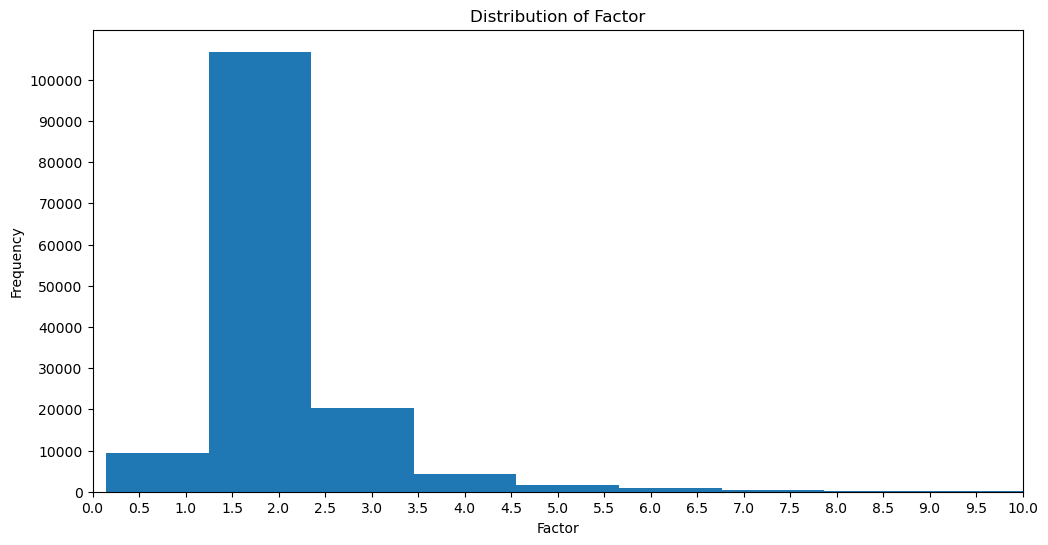

In [220]:
plt.figure(figsize=(12,6))

plt.hist(delivery_data['factor'], bins=70)

plt.xlim(0,10)

plt.yticks(np.arange(0, 110000, 10000))

plt.xticks(np.arange(0, 10.5, 0.5))

plt.xlabel('Factor')
plt.ylabel('Frequency')
plt.title('Distribution of Factor')

plt.show()